In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

from scipy.stats import spearmanr

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
import nltk

from nltk.corpus import wordnet as wn

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

from scipy.spatial.distance import squareform

from scipy.cluster.hierarchy import linkage

from scipy.cluster.hierarchy import dendrogram

import pickle

import matplotlib.pyplot as plt

import seaborn as sns


import networkx as nx

c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6834.90it/s]


In [2]:
# carico il dataset
taxonomic_tree = pd.read_csv("taxonomic_pairs.csv")

In [4]:
#creo set all_words con tutte le parole per poter fare embedding
all_words = set()

# sinonimi
all_words.update(taxonomic_tree["word1"])
all_words.update(taxonomic_tree["word2"])

print(all_words)
print(len(all_words))


{'boat', 'vehicle', 'hovercraft', 'vessel', 'steamroller', 'lander', 'craft', 'missile', 'luge', 'aircraft', 'ship', 'yacht', 'spacecraft', 'toboggan', 'galley', 'sled', 'bobsled', 'sidewinder', 'rocket', 'starship'}
20


In [5]:
#calcolo gli embedding una sola volta grazie a all_words, li metto in un dizionario
embeddings = {}

for word in all_words:
    
    embeddings[word] = model.encode(
        word,
        convert_to_tensor=True
    )


print("Embedding creati:", len(embeddings))

Embedding creati: 20


In [6]:
#salvo il dizionario così da non doverli calcolare ogni volta che apro il progetto

import pickle

with open("embeddings.pkl_2", "wb") as f:
    pickle.dump(embeddings, f)

In [2]:
#codice da eseguire per avere gli embedding

import pickle

with open("embeddings.pkl_2", "rb") as f:
    embeddings = pickle.load(f)

In [8]:
def add_cosine_similarity(df, col1, col2):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = embeddings[w1]
        emb2 = embeddings[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [9]:
#funzione applicata all'albero

taxonomic_df = add_cosine_similarity(
    taxonomic_tree,
    "word1",
    "word2"
)

print(taxonomic_df.head())

     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.417660
1  vehicle     missile                   2           0.399021
2  vehicle  sidewinder                   3           0.230047
3  vehicle       craft                   1           0.319384
4  vehicle    aircraft                   2           0.516191


In [10]:
#salvo i risultati
taxonomic_df.to_csv(
    "results_taxonomic_tree_similarity.csv",
    index=False
)


In [3]:
#per caricare dataset con cosine similarity

taxonomic_df = pd.read_csv("results_taxonomic_tree_similarity.csv")

In [4]:
#Calcolo la Cosine distance (1- cosine similarity)
taxonomic_df["cosine_distance"] = 1 - taxonomic_df["cosine_similarity"]

print(taxonomic_df.head())

     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809


In [5]:
#HEATMAP Distanza Tassonomica
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso = taxonomic_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(df_inverso.head())

     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809


In [6]:
#step 2: unisco i dataset
df_completo = pd.concat([taxonomic_df,df_inverso])

print(df_completo.head())
print(len(df_completo))


     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809
380


In [7]:
#carico grafo G
with open("taxonomy_graph.pkl", "rb") as f:
    G = pickle.load(f)

In [8]:
#costruisco matrice partendo dal grafo dell'albero tassonomico così che gli elementi siano in ordine gerarchicamente parlando
#la distanza floys_marshall corrisponde esattamente alla short_path_distance calcloata nel dataframe, è la distanza tassonomica

sub_sorted_keys = list(nx.topological_sort(G))

sub_G_undirected = G.to_undirected()

dist_matrix = nx.floyd_warshall_numpy(
    sub_G_undirected,
    nodelist=sub_sorted_keys
)

print(dist_matrix.shape)
print(dist_matrix)

(20, 20)
[[0. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3.]
 [1. 0. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 0. 2. 2. 1. 1. 1. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 2. 0. 2. 3. 3. 3. 1. 1. 1. 1. 3. 2. 2. 2. 2. 2. 2. 4.]
 [1. 2. 2. 2. 0. 3. 3. 3. 3. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 2.]
 [2. 3. 1. 3. 3. 0. 2. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 0. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 2. 0. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 0. 2. 2. 2. 4. 1. 1. 1. 1. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 0. 2. 2. 4. 3. 3. 3. 3. 1. 1. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 0. 2. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 2. 0. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 4. 0. 5. 5. 5. 5. 5. 5. 1.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 0. 2. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 0. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 2.

In [9]:
#creao lista ordinata di lemmi
ordered_words = [
    wn.synset(node).lemmas()[0].name()
    for node in sub_sorted_keys
]

print(ordered_words)

['vehicle', 'steamroller', 'sled', 'craft', 'rocket', 'bobsled', 'toboggan', 'luge', 'vessel', 'spacecraft', 'aircraft', 'hovercraft', 'missile', 'galley', 'boat', 'yacht', 'ship', 'starship', 'lander', 'sidewinder']


In [10]:
#creo matrice di cosine distance a partire dal dataframe
cosine_matrix = df_completo.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)

In [11]:
#cambio l'ordine degli elementi della matrice
cosine_matrix = cosine_matrix.reindex(
    index=ordered_words,
    columns=ordered_words
)

In [14]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix = cosine_matrix.copy()

for word in cosine_matrix.index:
    cosine_matrix.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix.shape)

print(cosine_matrix)
print(cosine_matrix.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.665897  0.687327  0.680616  0.582340  0.746979   
steamroller  0.665897     0.000000  0.754323  0.755771  0.612986  0.683510   
sled         0.687327     0.754323  0.000000  0.731186  0.711525  0.754041   
craft        0.680616     0.755771  0.731186  0.000000  0.739814  0.723290   
rocket       0.582340     0.612986  0.711525  0.739814  0.000000  0.746333   
bobsled      0.746979     0.683510  0.754041  0.723290  0.746333  0.000000   
toboggan     0.763065     0.732551  0.746734  0.803915  0.755824  0.713732   
luge         0.701698     0.766586  0.491581  0.680487  0.714840  0.659687   
vessel       0.567859     0.692417  0.791673  0.544082  0.707019  0.795184   
spacecraft   0.546482     0.691267  0.812617  0.637291  0.416971  0.699618   
aircraft     0.483809     0.632218  0.754224  

In [61]:
print(np.unique(dist_matrix))

[0. 1. 2. 3. 4. 5. 6.]


In [62]:
#Heatmap, prima faccio lista di matrici da visualizzare
mats = [taxonomic_norm,
        cosine_matrix.to_numpy()]  #la trasformo in un array

titles = ["Taxonomic Distance",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sub_sorted_keys
]

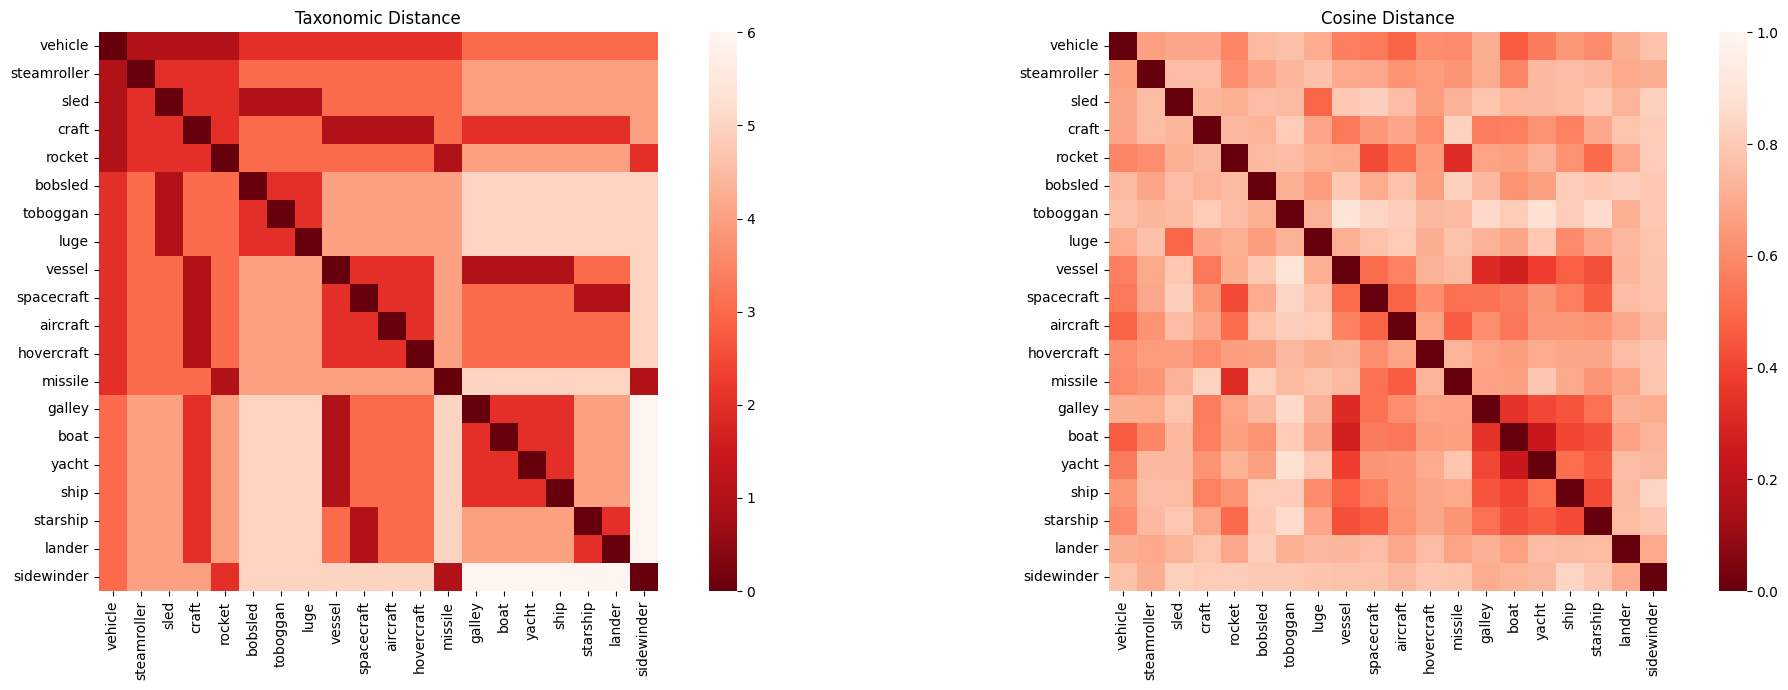

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=6,
    square=True
)

axes[0].set_title("Taxonomic Distance")
axes[0].tick_params(axis="x", rotation=90)
axes[0].tick_params(axis="y", rotation=0)

# Cosine distance
sns.heatmap(
    cosine_matrix.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    square=True
)

axes[1].set_title("Cosine Distance")
axes[1].tick_params(axis="x", rotation=90)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [71]:
#verificare la correlazione tra taxonomic distance e cosine distance

rho, p_value = spearmanr(
    taxonomic_df["taxonomic_distance"],
    taxonomic_df["cosine_distance"]
)

print(f"Spearman rho: {rho:.4f}")
print(f"p-value: {p_value:.12f}")

Spearman rho: 0.4328
p-value: 0.000000000449


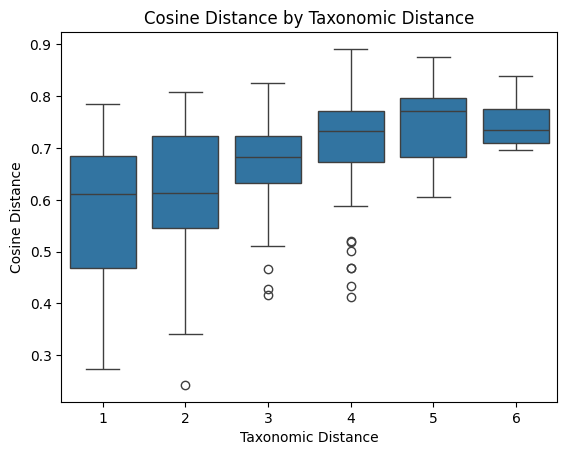

In [69]:
sns.boxplot(
    data=taxonomic_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Taxonomic Distance")
plt.ylabel("Cosine Distance")
plt.title("Cosine Distance by Taxonomic Distance")
plt.show()

In [72]:
taxonomic_df.groupby("taxonomic_distance")["cosine_distance"].agg(
    ["count", "mean", "std"]
)

,count,mean,std
taxonomic_distance,,,
1,19,0.571016,0.163105
2,37,0.613472,0.134805
3,49,0.665107,0.094077
4,48,0.702398,0.110195
5,31,0.747155,0.071637
6,6,0.749166,0.054129


In [ ]:
#INIZIO CLUSTERIZZAZIONE
#trasformo la matrice in forma scypy: estrae il triangolo superiore della matrice e lo convere in un vettore
distance_vector = squareform(cosine_matrix.values)

In [18]:

Z = linkage(
    distance_vector,
    method="average"
)

print(Z)

[[14.         15.          0.24287635  2.        ]
 [ 8.         13.          0.31545955  2.        ]
 [ 4.         12.          0.31936574  2.        ]
 [20.         21.          0.35028161  4.        ]
 [16.         17.          0.41304839  2.        ]
 [23.         24.          0.46012726  6.        ]
 [ 9.         22.          0.46841885  3.        ]
 [ 0.         10.          0.48380893  2.        ]
 [ 2.          7.          0.4915815   2.        ]
 [26.         27.          0.53188352  5.        ]
 [ 3.         25.          0.5927076   7.        ]
 [29.         30.          0.63156387 12.        ]
 [ 1.         11.          0.65252438  2.        ]
 [ 5.         32.          0.67502216  3.        ]
 [18.         19.          0.69598728  2.        ]
 [31.         33.          0.69970607 15.        ]
 [28.         35.          0.73180174 17.        ]
 [34.         36.          0.75181934 19.        ]
 [ 6.         37.          0.78782162 20.        ]]


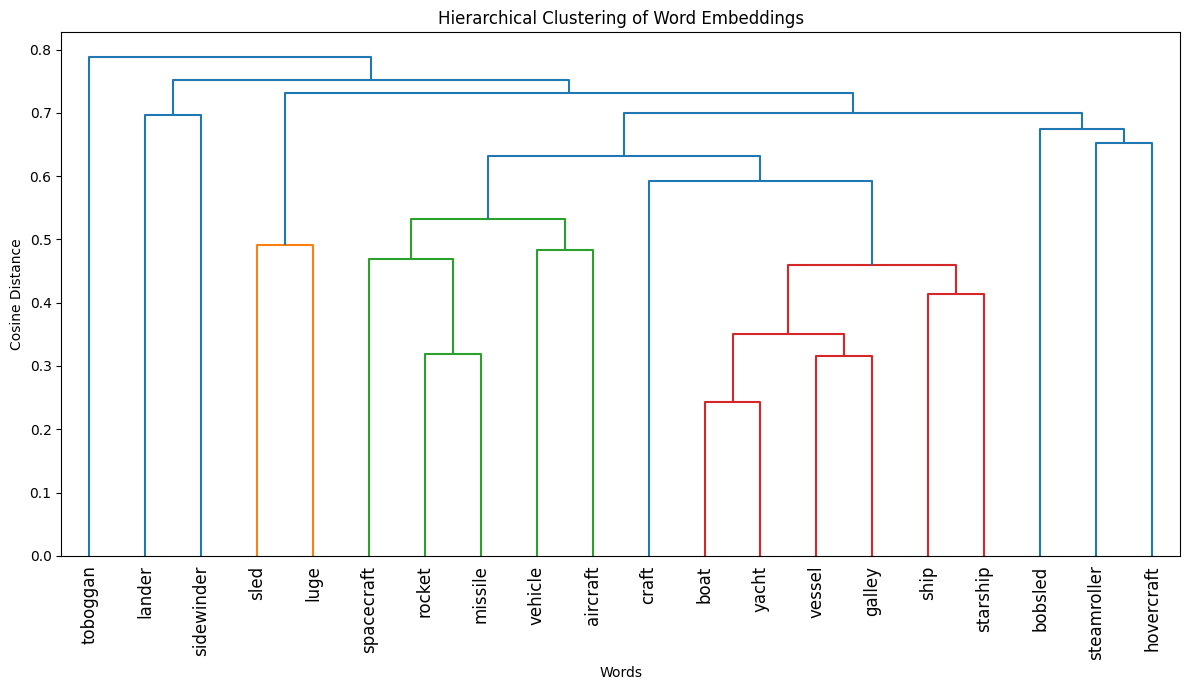

In [20]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z,
    labels=cosine_matrix.index.tolist(),
    leaf_rotation=90
)

plt.xlabel("Words")
plt.ylabel("Cosine Distance")
plt.title("Hierarchical Clustering of Word Embeddings")

plt.tight_layout()
plt.show()

In [12]:
#k-means clusters
X = np.array([embeddings[word] for word in cosine_matrix.index])

print(X.shape)

(20, 384)


In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

In [14]:
cluster_df = pd.DataFrame({
    "word": cosine_matrix.index,
    "cluster": clusters
})

cluster_df = cluster_df.sort_values("cluster")

print(cluster_df)

           word  cluster
3         craft        0
14         boat        0
11   hovercraft        0
15        yacht        0
13       galley        0
8        vessel        0
17     starship        0
16         ship        0
4        rocket        1
9    spacecraft        1
10     aircraft        1
12      missile        1
1   steamroller        1
18       lander        1
0       vehicle        1
7          luge        2
2          sled        2
5       bobsled        2
6      toboggan        2
19   sidewinder        2


In [15]:
for cluster in sorted(cluster_df["cluster"].unique()):
    
    words = cluster_df[
        cluster_df["cluster"] == cluster
    ]["word"].tolist()
    
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Cluster 0:
  craft, boat, hovercraft, yacht, galley, vessel, starship, ship
Cluster 1:
  rocket, spacecraft, aircraft, missile, steamroller, lander, vehicle
Cluster 2:
  luge, sled, bobsled, toboggan, sidewinder
